# 1. Loading the Data

In [78]:
import pandas as pd

In [79]:
df=pd.read_csv('heart.csv')

In [80]:
df.head(4)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0


In [81]:
df.shape

(1025, 14)

#2. Data Cleaning

In [82]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [83]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [84]:
# Drop duplicates if any
df = df.drop_duplicates()



# 3. Exploratory Data Analysis (EDA)

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

#sumary Statistic
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


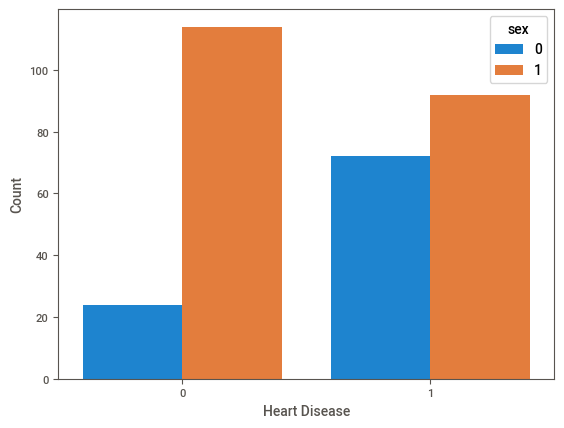

In [86]:
# Visualize the distribution of the target variable (heart disease)
sns.countplot(x='target', hue='sex', data=df)
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

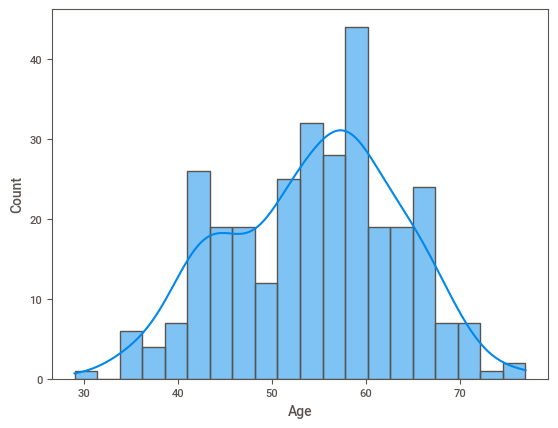

In [87]:
# Visualizing age distribution
sns.histplot(df['age'], bins=20, kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [88]:
!pip install ydata-profiling


##  Profile Report

In [89]:
import pandas_profiling as pp

# Generate Sweetviz report
pp.ProfileReport(df)



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

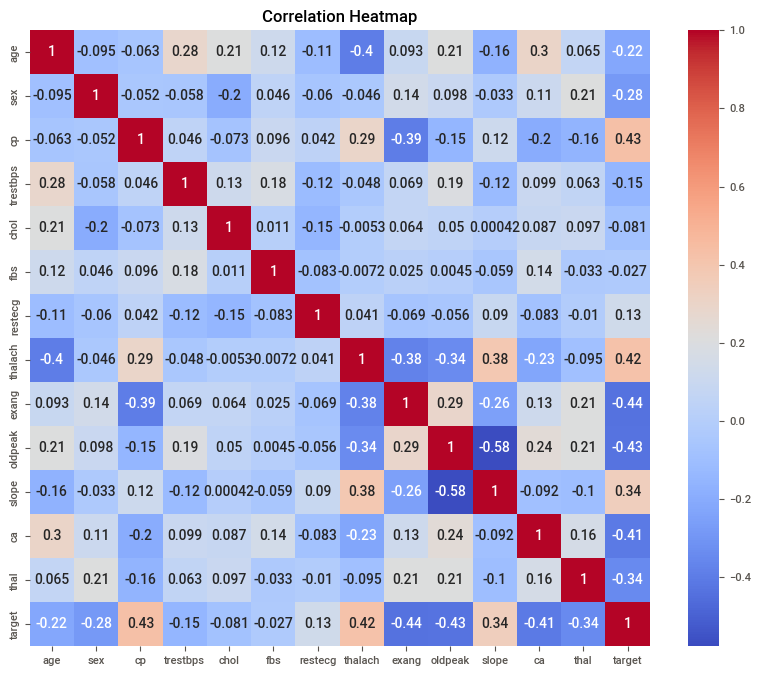

In [90]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Data Preprocessing

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [92]:
# Define features and target variable
X = df.drop('target', axis=1)
y = df['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [93]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
X_test.shape

(61, 13)

In [95]:
X_train.shape

(241, 13)

# 5. Feature Engineering

In [54]:
bins = [29, 39, 49, 59, 69, 79]
labels = ['30-39', '40-49', '50-59', '60-69', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 6. Model Training and Testing

## Logistic Regression

Confusion Matrix:
[[21 11]
 [ 3 26]]


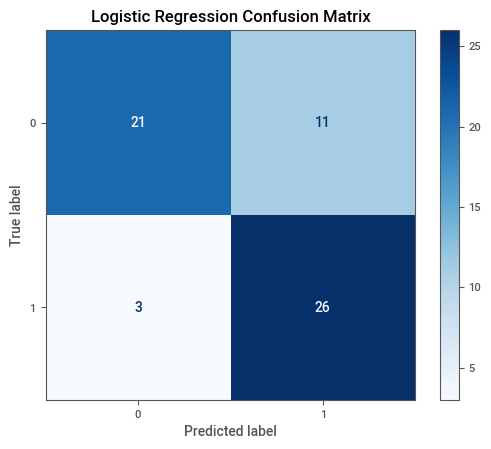


Accuracy of Logistic Regression: 77.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        32
           1       0.70      0.90      0.79        29

    accuracy                           0.77        61
   macro avg       0.79      0.78      0.77        61
weighted avg       0.79      0.77      0.77        61



In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, lr_predictions)

# Print Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Display Confusion Matrix as a Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Print Accuracy
print(f"\nAccuracy of Logistic Regression: {lr_accuracy * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, lr_predictions))


## Random Forest Classifier

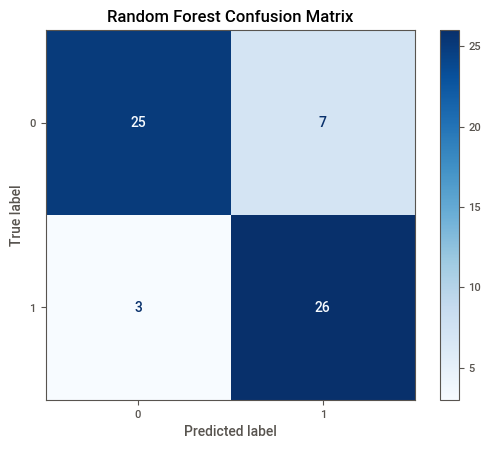

Accuracy of Random Forest: 83.61%
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [97]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, rf_predictions)

# Display Confusion Matrix as a Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Print Accuracy
print(f"Accuracy of Random Forest: {rf_accuracy * 100:.2f}%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, rf_predictions))


## Support Vector Machine (SVM)

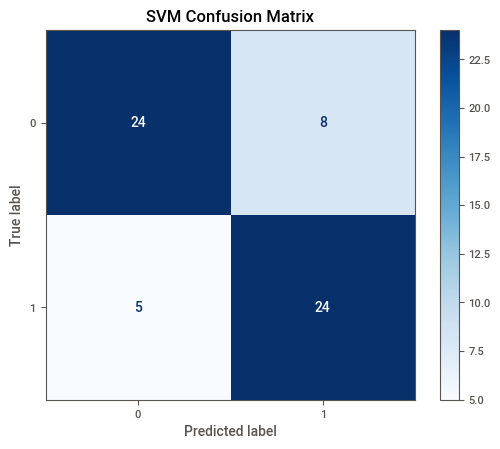

Accuracy of SVM: 78.69%
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.75      0.83      0.79        29

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [98]:
from sklearn.svm import SVC

# Train SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, svm_predictions)

# Display Confusion Matrix as a Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()

# Print Accuracy
print(f"Accuracy of SVM: {svm_accuracy * 100:.2f}%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, svm_predictions))


## K-Nearest Neighbors (KNN)

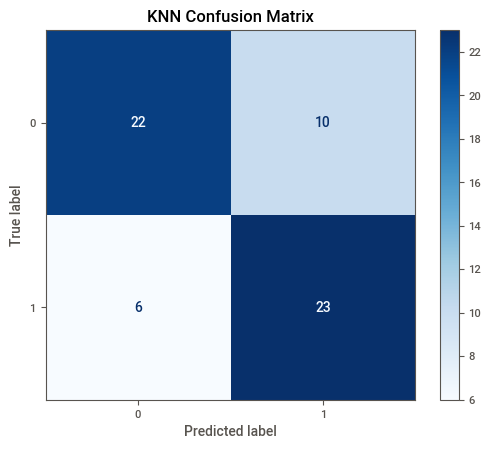

Accuracy of KNN: 73.77%
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.70      0.79      0.74        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



In [99]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
knn_predictions = knn_model.predict(X_test)

# Accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, knn_predictions)

# Display Confusion Matrix as a Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("KNN Confusion Matrix")
plt.show()

# Print Accuracy
print(f"Accuracy of KNN: {knn_accuracy * 100:.2f}%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, knn_predictions))


## XGBoost

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [11:10:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


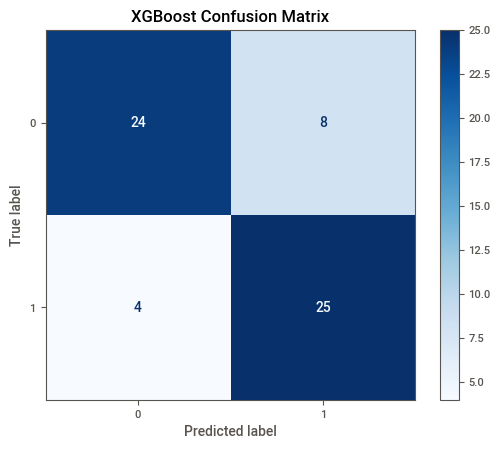

Accuracy of XGBoost: 80.33%
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



In [100]:
import xgboost as xgb

# Train XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_predictions = xgb_model.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_predictions)

# Display Confusion Matrix as a Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix")
plt.show()

# Print Accuracy
print(f"Accuracy of XGBoost: {xgb_accuracy * 100:.2f}%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, xgb_predictions))


In [73]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.8 MB/s eta 0:00:00
